In [247]:
import time 
import warnings
import numpy as np 
import pandas as pd
import requests
import matplotlib.pyplot as plt

import torch
import torch.nn as nn # for the neuro network 
from torch.utils.data import TensorDataset, DataLoader 
from sklearn.linear_model import Ridge 

In [248]:
import requests, pandas as pd, time

url = "https://api.binance.com/api/v3/klines"

all_rows = []
current = int(pd.to_datetime("2017-08-17", utc=True).timestamp() * 1000)
end_ms  = int(pd.to_datetime("2026-09-29", utc=True).timestamp() * 1000)

while current < end_ms:
    res = requests.get(url, params={
        "symbol": "BTCUSDT", "interval": "1h",
        "startTime": current, "endTime": end_ms, "limit": 1000
    }).json()

    all_rows.extend(res)
    current = res[-1][0] + 1
    time.sleep(0.03)
    print(f"fetched {len(all_rows)} rows")

print(f"\nTotal: {len(all_rows)} rows")
print(all_rows[0])

fetched 1000 rows
fetched 2000 rows
fetched 3000 rows
fetched 4000 rows
fetched 5000 rows
fetched 6000 rows
fetched 7000 rows
fetched 8000 rows
fetched 9000 rows
fetched 10000 rows
fetched 11000 rows
fetched 12000 rows
fetched 13000 rows
fetched 14000 rows
fetched 15000 rows
fetched 16000 rows
fetched 17000 rows
fetched 18000 rows
fetched 19000 rows
fetched 20000 rows
fetched 21000 rows
fetched 22000 rows
fetched 23000 rows
fetched 24000 rows
fetched 25000 rows
fetched 26000 rows
fetched 27000 rows
fetched 28000 rows
fetched 29000 rows
fetched 30000 rows
fetched 31000 rows
fetched 32000 rows
fetched 33000 rows
fetched 34000 rows
fetched 35000 rows
fetched 36000 rows
fetched 37000 rows
fetched 38000 rows
fetched 39000 rows
fetched 40000 rows
fetched 41000 rows
fetched 42000 rows
fetched 43000 rows
fetched 44000 rows
fetched 45000 rows
fetched 46000 rows
fetched 47000 rows
fetched 48000 rows
fetched 49000 rows
fetched 50000 rows
fetched 51000 rows
fetched 52000 rows
fetched 53000 rows
fe

In [249]:
columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
]
df = pd.DataFrame(all_rows, columns=columns)
print(df.head())

       open_time           open           high            low          close  \
0  1502942400000  4261.48000000  4313.62000000  4261.32000000  4308.83000000   
1  1502946000000  4308.83000000  4328.69000000  4291.37000000  4315.32000000   
2  1502949600000  4330.29000000  4345.45000000  4309.37000000  4324.35000000   
3  1502953200000  4316.62000000  4349.99000000  4287.41000000  4349.99000000   
4  1502956800000  4333.32000000  4377.85000000  4333.32000000  4360.69000000   

        volume     close_time quote_asset_volume  number_of_trades  \
0  47.18100900  1502945999999    202366.13839304               171   
1  23.23491600  1502949599999    100304.82356749               102   
2   7.22969100  1502953199999     31282.31266989                36   
3   4.44324900  1502956799999     19241.05829986                25   
4   0.97280700  1502960399999      4239.50358563                28   

  taker_buy_base_asset_volume taker_buy_quote_asset_volume ignore  
0                 35.16050300 

In [250]:
df = df.drop(columns = ["ignore"])

In [251]:
print(df.head())

       open_time           open           high            low          close  \
0  1502942400000  4261.48000000  4313.62000000  4261.32000000  4308.83000000   
1  1502946000000  4308.83000000  4328.69000000  4291.37000000  4315.32000000   
2  1502949600000  4330.29000000  4345.45000000  4309.37000000  4324.35000000   
3  1502953200000  4316.62000000  4349.99000000  4287.41000000  4349.99000000   
4  1502956800000  4333.32000000  4377.85000000  4333.32000000  4360.69000000   

        volume     close_time quote_asset_volume  number_of_trades  \
0  47.18100900  1502945999999    202366.13839304               171   
1  23.23491600  1502949599999    100304.82356749               102   
2   7.22969100  1502953199999     31282.31266989                36   
3   4.44324900  1502956799999     19241.05829986                25   
4   0.97280700  1502960399999      4239.50358563                28   

  taker_buy_base_asset_volume taker_buy_quote_asset_volume  
0                 35.16050300        

In [252]:
df["timetamp"] = pd.to_datetime(df["open_time"] , unit="ms" , utc=True )

for c in [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"
]: 
    df[c] = df[c].astype(float) # so here we can convert the data type into float


In [253]:
df = df.sort_values("timetamp").drop_duplicates("timetamp").reset_index(drop=True) 
# so here the sort values make the time sorted in stead of make the 11 pm and 1 am look close it make it look distant as it should so the module can understand 
# and for the drop it drop duplicates 
#utc = true for when i drop the column 5 it get replaced with the next one instead of being null 

In [254]:
print(df.columns.tolist())

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'timetamp']


In [255]:
print(df[["volume", "quote_asset_volume"]].describe())
print(f"Mean price implied: {(df['quote_asset_volume'] / df['volume']).mean():.0f}")

print(df["number_of_trades"].describe())

violations = (df["taker_buy_base_asset_volume"] > df["volume"] * 1.001).sum()
print(f"Violations: {violations}")   

df["taker_buy_ratio"] = (
    df["taker_buy_base_asset_volume"] / (df["volume"] + 1e-8)
)
print(df["taker_buy_ratio"].describe())  

              volume  quote_asset_volume
count   79789.000000        7.978900e+04
mean     2458.483431        7.221173e+07
std      3798.804562        1.004060e+08
min         0.000000        0.000000e+00
25%       691.802800        1.444957e+07
50%      1312.636120        3.922556e+07
75%      2577.840400        9.109349e+07
max    137207.188600        3.005634e+09
Mean price implied: 38974
count    7.978900e+04
mean     8.422865e+04
std      1.124776e+05
min      0.000000e+00
25%      1.743400e+04
50%      4.463000e+04
75%      1.029870e+05
max      3.520247e+06
Name: number_of_trades, dtype: float64
Violations: 0
count    79789.000000
mean         0.495239
std          0.069289
min          0.000000
25%          0.460291
50%          0.496335
75%          0.531524
max          1.000000
Name: taker_buy_ratio, dtype: float64


In [256]:
df["return"] = ((df["close"]-df["open"] )/df["open"] )*100

In [257]:
df["hourly_range"] = (df["high"] - df["low"]) / df["low"] * 100

In [258]:
#close-to-close return:
#(Ci - Ci-1) / Ci-1 * 100 
df["rt_cc"] = ((df["close"] - df["close"].shift(1)) / df["close"].shift(1)) * 100

In [259]:
df["range_ma_24"] = df["hourly_range"].rolling(24).mean() # moving average of 24 hour range 
df["range_ma_168"] = df["hourly_range"].rolling(168).mean() # moving average of 168 hour range

In [260]:
df["volatility_24"] = df["rt_cc"].rolling(24).std()

In [261]:
df["volume_ma_24"] = df["volume"].rolling(24).mean()
df["volume_ratio"] = df["volume"] / (df["volume_ma_24"] + 1e-8)

In [262]:
#cyclical time encoding:(its an important concept for seprating between the 23 pm  and 1 am )
tau = 2 * np.pi  # Full circle constant (2 * pi)

hour = df["timetamp"].dt.hour
dow = df["timetamp"].dt.dayofweek

df[["hour_sin", "hour_cos"]] = np.column_stack(
    [np.sin(tau * hour / 24), np.cos(tau * hour / 24)]
)

df[["dow_sin", "dow_cos"]] = np.column_stack(
    [np.sin(tau * dow / 7), np.cos(tau * dow / 7)]
)

In [263]:
df["volume_change"] = df["volume"].pct_change() * 100

df["range_ma_720"] = df["hourly_range"].rolling(720).mean()
df["volatility_168"] = df["rt_cc"].rolling(168).std()

df["ma_24_price"]  = df["close"].rolling(24).mean()
df["ma_168_price"] = df["close"].rolling(168).mean()
df["distance_ma_24"]  = (df["close"] - df["ma_24_price"])  / (df["ma_24_price"]  + 1e-8)
df["distance_ma_168"] = (df["close"] - df["ma_168_price"]) / (df["ma_168_price"] + 1e-8)

for lag in (1, 2, 3, 6, 12):
    df[f"range_lag_{lag}"] = df["hourly_range"].shift(lag)

df["is_weekend"] = (df["timetamp"].dt.dayofweek >= 5).astype(float)

In [264]:
df["taker_buy_ratio"] = (
    df["taker_buy_base_asset_volume"] / (df["volume"] + 1e-8)
)
df["order_flow_imbalance"] = (
    (2 * df["taker_buy_base_asset_volume"] - df["volume"])
    / (df["volume"] + 1e-8)
)
df["avg_trade_size"]     = df["volume"] / (df["number_of_trades"] + 1e-8)
df["avg_trade_size_usd"] = df["quote_asset_volume"] / (df["number_of_trades"] + 1e-8)

In [265]:
df["vol_regime"]      = df["volatility_24"] / (df["volatility_168"] + 1e-8)
df["range_vs_ma_168"] = df["hourly_range"] / (df["range_ma_168"] + 1e-8)
df["range_vs_ma_720"] = df["hourly_range"] / (df["range_ma_720"] + 1e-8)

df["high_vol_streak"] = (
    (df["hourly_range"] > df["range_ma_24"]).rolling(6).sum()
)

df["roll_max_720"]  = df["close"].rolling(720).max()
df["drawdown_720"]  = (df["close"] - df["roll_max_720"]) / (df["roll_max_720"] + 1e-8)

df["return_skew_168"] = df["rt_cc"].rolling(168).skew()

In [266]:
df["trade_count_change"] = df["number_of_trades"].pct_change() * 100

In [267]:
df["vwap_hour"]     = df["quote_asset_volume"] / (df["volume"] + 1e-8)
df["close_vs_vwap"] = (df["close"] - df["vwap_hour"]) / (df["vwap_hour"] + 1e-8) * 100

In [268]:
df["ofi_ma_24"]        = df["order_flow_imbalance"].rolling(24).mean()
df["ofi_std_24"]       = df["order_flow_imbalance"].rolling(24).std()
df["taker_buy_ma_24"]  = df["taker_buy_ratio"].rolling(24).mean()
df["trade_size_ma_24"] = df["avg_trade_size"].rolling(24).mean()
df["trade_size_ratio"] = df["avg_trade_size"] / (df["trade_size_ma_24"] + 1e-8)

In [269]:
for lag in (1, 2, 3):
    df[f"trade_ratio_lag_{lag}"] = df["taker_buy_ratio"].shift(lag)

In [270]:
for lag in (1, 2, 3, 6, 12):
    df[f"ofi_lag_{lag}"] = df["order_flow_imbalance"].shift(lag)

In [271]:
df["next_hour_range"] = df["hourly_range"].shift(-1)

In [272]:
df["target"] = df["next_hour_range"] / (df["range_ma_24"] + 1e-8)
df["target"] = df["target"].clip(0, 100)

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'timetamp']

In [273]:
def fetch_funding(start_ms, end_ms):
    records, cur_time = [], start_ms
    while cur_time < end_ms:
        res = requests.get("https://fapi.binance.com/fapi/v1/fundingRate",
                           params={"symbol": "BTCUSDT",
                                   "startTime": cur_time, "limit": 1000},
                           timeout=10)
        data = res.json()
        if not data:
            break
        records.extend(data)
        cur_time = data[-1]["fundingTime"] + 1
        time.sleep(0.02)

    df_f = pd.DataFrame(records)
    df_f["timestamp"] = pd.to_datetime(df_f["fundingTime"], unit="ms", utc=True)
    df_f["funding_rate"] = df_f["fundingRate"].astype(float)
    df_f["funding_rate_change"] = df_f["funding_rate"].diff()
    mean_8h = df_f["funding_rate"].rolling(21, min_periods=7).mean()
    std_8h  = df_f["funding_rate"].rolling(21, min_periods=7).std() + 1e-8
    df_f["z_funding"] = (df_f["funding_rate"] - mean_8h) / std_8h
    return df_f[["timestamp", "funding_rate", "funding_rate_change", "z_funding"]]

start_ms = int(df["timetamp"].min().timestamp() * 1000)
end_ms   = int(df["timetamp"].max().timestamp() * 1000)
df_funding = fetch_funding(start_ms, end_ms)

df = pd.merge_asof(df.sort_values("timetamp"),
                   df_funding.sort_values("timestamp"),
                   left_on="timetamp", right_on="timestamp",
                   direction="backward")

df[["funding_rate", "funding_rate_change", "z_funding"]] = (
    df[["funding_rate", "funding_rate_change", "z_funding"]].ffill().fillna(0)
)



In [274]:
cols_ohlcv = [
    "return",              
    "hourly_range",       
    "rt_cc",            
    "volume_change",       
    "volume_ratio",    
    "range_ma_24",
    "range_ma_168",
    "range_ma_720",
    "volatility_24",
    "volatility_168",
    "distance_ma_24",
    "distance_ma_168",
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "is_weekend",
    "range_lag_1", "range_lag_2", "range_lag_3",
    "range_lag_6", "range_lag_12",
    "vol_regime",
    "range_vs_ma_168",
    "range_vs_ma_720",
    "high_vol_streak",
    "drawdown_720",
    "return_skew_168",
]
cols_orderflow = [
    "taker_buy_ratio",         
    "order_flow_imbalance",   
    "close_vs_vwap",          
    "avg_trade_size",         
    "avg_trade_size_usd",     
    "trade_size_ratio",       
    "trade_count_change", 
    "ofi_ma_24",
    "ofi_std_24",
    "taker_buy_ma_24",
    "trade_size_ma_24",
    "ofi_lag_1", "ofi_lag_2", "ofi_lag_3", "ofi_lag_6", "ofi_lag_12",
    "trade_ratio_lag_1", "trade_ratio_lag_2", "trade_ratio_lag_3",
]

cols_funding = ["funding_rate", "funding_rate_change", "z_funding"]

feature_cols = cols_ohlcv + cols_orderflow + cols_funding

to make a mlp :

layer one : linear transformation 
x*W + b = z

there is vector (x) [ x , y , z] * weights (W) [[ x1 , y1 , z1 ] , [ x2 , y2 , z2 ] ,[ x3 , y3 , z3 ]] + bias (b) [ x , y , z ]  = linear output(z)

so here we using linear algebra to solve this one 

ReLU activation function 

neuron if its zero is clipped (disactivated)
neuron if its between 1 and bigger than zero it active

as example neuron a1,1 max(0 , 0.45) active 
           neuron a1,2 max(0 , -0.23)clipped 

layer 2 : output trasformation 
ŷ = a1 W2 + b2


Step-by-Step Mathematical Flow :
Here is how a 1D feature vector $x$ moves through the 2-layer pipeline:
Linear Projection 1:$$z_1 = x W_1 + b_1$$

Maps your raw input features $x$ into a hidden representation $z_1$.

Nonlinear Filtering (ReLU):
$$a_1 = \max(0, z_1)$$
Zeros out negative activation values element-wise, giving the network the ability to fit non-linear patterns.

Final Linear Projection:
$$\hat{y} = a_1 W_2 + b_2$$
Combines the filtered hidden features into your final scalar prediction $\hat{y}$ (such as next-hour volatility).

In [275]:
needed = feature_cols + ["target"]

df_clean = df.replace([np.inf, -np.inf], np.nan)

df_clean = df_clean.dropna(subset=needed).reset_index(drop=True)

print("Total rows:", len(df_clean))
print("Features:", len(feature_cols))
print("First date:", df_clean["timetamp"].min())
print("Last date: ", df_clean["timetamp"].max())

Total rows: 79066
Features: 50
First date: 2017-09-16 09:00:00+00:00
Last date:  2026-09-28 23:00:00+00:00


In [276]:
split_point = int(len(df_clean) * 0.8)

x = df_clean[feature_cols].values.astype("float32")
y = df_clean["target"].values.astype("float32")  

x_train = x[:split_point]
x_test  = x[split_point:]
y_train = y[:split_point]
y_test  = y[split_point:]

In [277]:
mean = x_train.mean(axis=0)

std = x_train.std(axis=0) + 1e-8

x_train = (x_train - mean) / std

x_test = (x_test - mean) / std

y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

print("X_train shape:", x_train.shape)
print("X_test shape: ", x_test.shape)


X_train shape: (63252, 50)
X_test shape:  (15814, 50)


$$z = \frac{x - \mu}{\sigma}$$Where:$x$ is the original value.$\mu$ (mu) is the mean (average) of that feature across the training set.$\sigma$ (sigma) is the standard deviation.Step 1: Assume Training StatisticsSuppose we have a training set of student records with these calculated statistics:SAT Score ($X_1$):Mean ($\mu_1$) = 1000Standard Deviation ($\sigma_1$) = 200GPA ($X_2$):Mean ($\mu_2$) = 3.0Standard Deviation ($\sigma_2$) = 0.5Step 2: Unscaled Raw Input ComparisonLet's evaluate a high-performing student with:SAT Score: $1400$GPA: $4.0$If passed directly to a model with equal weights ($w_1 = 1, w_2 = 1$):SAT contribution = $1400$GPA contribution = $4.0$The raw SAT value completely drowns out the GPA value simply due to scale.Step 3: Calculate Standardized Values ($z$-scores)1. Standardizing SAT Score ($1400$)$$z_{\text{SAT}} = \frac{1400 - 1000}{200} = \frac{400}{200} = 2.0$$2. Standardizing GPA ($4.0$)$$z_{\text{GPA}} = \frac{4.0 - 3.0}{0.5} = \frac{1.0}{0.5} = 2.0$$Final ResultFeatureRaw ValueMean (μ)Std Dev (σ)Scaled Value (z)MeaningSAT14001000200$+2.0$2 std devs above averageGPA4.03.00.5$+2.0$2 std devs above averageAfter applying (X - mean) / std, both values equal $+2.0$. The model now views both achievements as equally impressive relative to their respective distributions.

In [289]:
model = nn.Sequential(
    nn.Linear(len(feature_cols), 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)
# Weights: *32 = 1,536    Biases:32              Total parameters in Layer 1: 1,568 trainable numbers

print(model)

Sequential(
  (0): Linear(in_features=50, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)


In [290]:

x_t = torch.tensor(x_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

loader = DataLoader(TensorDataset(x_t, y_t), batch_size=128, shuffle=True)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [291]:
for epoch in range(30):
    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()       
        preds = model(xb)            
        loss = loss_fn(preds, yb)    
        loss.backward()             
        optimizer.step()       

        total_loss += loss.item()

    avg = total_loss / len(loader)
    print("epoch", epoch + 1, "| loss", round(avg, 5))

epoch 1 | loss 0.60311
epoch 2 | loss 0.53722
epoch 3 | loss 0.52904
epoch 4 | loss 0.52479
epoch 5 | loss 0.52233
epoch 6 | loss 0.52023
epoch 7 | loss 0.51878
epoch 8 | loss 0.51816
epoch 9 | loss 0.51739
epoch 10 | loss 0.51668
epoch 11 | loss 0.51575
epoch 12 | loss 0.51798
epoch 13 | loss 0.51359
epoch 14 | loss 0.51315
epoch 15 | loss 0.51302
epoch 16 | loss 0.51263
epoch 17 | loss 0.51349
epoch 18 | loss 0.54419
epoch 19 | loss 0.51561
epoch 20 | loss 0.5106
epoch 21 | loss 0.50999
epoch 22 | loss 0.50963
epoch 23 | loss 0.51003
epoch 24 | loss 0.50954
epoch 25 | loss 0.50941
epoch 26 | loss 0.50864
epoch 27 | loss 0.50949
epoch 28 | loss 0.5088
epoch 29 | loss 0.50802
epoch 30 | loss 0.50891


In [293]:
with torch.no_grad():
    x_test_t = torch.tensor(x_test)
    preds_log = model(x_test_t).numpy().flatten()

preds = np.expm1(preds_log)

def r2(real, guess):
    top    = ((real - guess) ** 2).sum()
    bottom = ((real - real.mean()) ** 2).sum()
    return 1 - top / bottom

nn_r2    = r2(y_test, preds)
naive    = np.full(len(y_test), y_train.mean())
naive_r2 = r2(y_test, naive)

print("NN R²:    ", round(nn_r2, 4))
print("Naive R²: ", round(naive_r2, 4))

NN R²:     -5.1408
Naive R²:  -1e-04


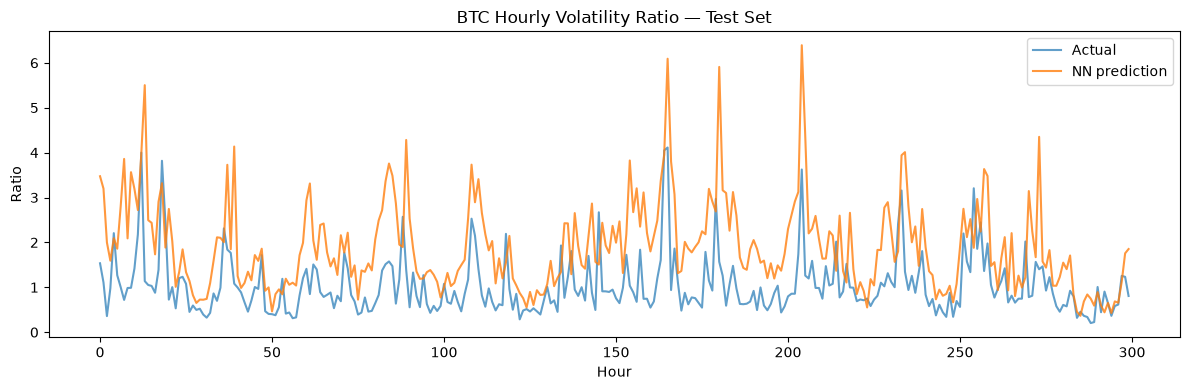

In [286]:
n = 300 

plt.figure(figsize=(12, 4))
plt.plot(y_test[:n], label="Actual", alpha=0.7)
plt.plot(preds[:n], label="NN prediction", alpha=0.8)
plt.title("BTC Hourly Volatility Ratio — Test Set")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()